# Sensitivity of BBN observables to physical parameters

## What this notebook computes

We compute the **logarithmic sensitivity** of each BBN observable $O$ to each
physical parameter $p$:
$$
S(O, p) \equiv \frac{\partial \ln O}{\partial \ln p}
\approx \frac{\ln O(p\,(1+\delta)) - \ln O(p\,(1-\delta))}{2\,\ln(1 + \delta)},
$$
evaluated by a symmetric finite difference with a 1% step ($\delta = 0.01$).

This dimensionless number tells you: **if parameter $p$ changes by 1%, by what
percentage does observable $O$ change?**

## Parameters varied

| Group | Parameters | Mechanism |
|-------|------------|-----------|
| Nuclear rates | All 12 key reaction rates | `NP_delta_rxn` — fractional additive shift to the median rate |
| Weak sector | Neutron lifetime τ_n | `tau_n` parameter |
| Gravity | Newton constant G_N | `GN` parameter |
| Cosmology | Baryon density Ω_b h², ΔNeff | `Omegabh2`, `DeltaNeff` parameters |

## Observables

$Y_P$ (He-4 mass fraction), D/H, ³He/H, ⁷Li/H

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pyprimat.main import PyPR
from pyprimat.config import DEFAULT_PARAMS

In [2]:
# ---------------------------------------------------------------------------
# Fiducial run — all parameters at their default values
# ---------------------------------------------------------------------------
# Omegabh2 does not affect the n<->p weak-rate fingerprint (see
# pyprimat.weak_rates), so this run loads the shipped rates/weak/*.txt
# cache directly -- no compute_nTOp/save_nTOp bookkeeping needed.

FIDUCIAL = {
    'Omegabh2':          0.02285,
    'network':          'small',
    'verbose':      False,
}

r0 = PyPR(params=FIDUCIAL).PyPRresults()
print("Fiducial run done.")
print(f"  YP    = {r0['YPBBN']:.6f}")
print(f"  D/H   = {r0['DoH']:.4e}")
print(f"  He3/H = {r0['He3oH']:.4e}")
print(f"  Li7/H = {r0['Li7oH']:.4e}")

BASE = FIDUCIAL

OBSERVABLES = ['YPBBN', 'DoH', 'He3oH', 'Li7oH']
OBS_LABELS  = [r'$Y_P$', r'D/H', r'$^3$He/H', r'$^7$Li/H']

def run(params):
    """Run PyPRIMAT with given params (merges with BASE) and return the 4 observables."""
    r = PyPR(params={**BASE, **params, 'verbose': False}).PyPRresults()
    return np.array([r[q] for q in OBSERVABLES])

fid_vals = np.array([r0[q] for q in OBSERVABLES])

Fiducial run done.
  YP    = 0.247087
  D/H   = 2.3623e-05
  He3/H = 1.0275e-05
  Li7/H = 5.7671e-10


In [3]:
# ---------------------------------------------------------------------------
# Helper: logarithmic sensitivity via symmetric finite difference
# ---------------------------------------------------------------------------
# For a parameter p varied by a fractional step δ,
# S(O, p) ≈ [ln O(p*(1+δ)) - ln O(p*(1-δ))] / [2*ln(1+δ)]
# With δ=0.01 this is accurate to O(δ²).

def log_sensitivity(run_plus, run_minus, delta=0.01):
    """Logarithmic sensitivity from two bracketing runs."""
    return (np.log(run_plus) - np.log(run_minus)) / (2 * np.log(1 + delta))

DELTA = 0.01   # 1% fractional step

In [4]:
# ---------------------------------------------------------------------------
# 1. Sensitivity to nuclear reaction rates
# ---------------------------------------------------------------------------
# We use the NP_delta_rxn mechanism: setting NP_delta_rxn = δ multiplies
# rate rxn by (1 + δ) relative to its median value.
# rescale_nuclear_rates must be True to activate this.
# The logarithmic sensitivity is then the standard finite-difference formula:
#   S = [ln O(rate*(1+δ)) - ln O(rate*(1-δ))] / [2*ln(1+δ)]

from pyprimat.main import PyPR
RATE_NAMES = list(PyPR().cfg.p_rxn.keys())[:12]
RATE_LABELS = [
    r'p+n→d+γ',
    r'd+p→³He+γ',
    r'd+d→³He+n',
    r'd+d→t+p',
    r't+p→⁴He+γ',
    r't+d→⁴He+n',
    r't+⁴He→⁷Li+γ',
    r'³He+n→t+p',
    r'³He+d→⁴He+p',
    r'³He+⁴He→⁷Be+γ',
    r'⁷Be+n→⁷Li+p',
    r'⁷Li+p→⁴He+⁴He',
]

print("Computing nuclear rate sensitivities...")
rate_sens = np.zeros((len(RATE_NAMES), len(OBSERVABLES)))

for i, rxn in enumerate(RATE_NAMES):
    key = f'NP_delta_{rxn}'
    rp  = run({'rescale_nuclear_rates': True, key: +DELTA})
    rm  = run({'rescale_nuclear_rates': True, key: -DELTA})
    rate_sens[i] = log_sensitivity(rp, rm, DELTA)
    print(f"  {RATE_LABELS[i]:<22}  YP: {rate_sens[i,0]:+.4f}  D/H: {rate_sens[i,1]:+.4f}")

print("Done.")

Computing nuclear rate sensitivities...
  p+n→d+γ                 YP: +0.0048  D/H: -0.1969
  d+p→³He+γ               YP: +0.0002  D/H: -0.3569
  d+d→³He+n               YP: +0.0060  D/H: -0.5470
  d+d→t+p                 YP: +0.0052  D/H: -0.4599
  t+p→⁴He+γ               YP: -0.0000  D/H: -0.0013
  t+d→⁴He+n               YP: +0.0000  D/H: -0.0002
  t+⁴He→⁷Li+γ             YP: -0.0000  D/H: -0.0005
  ³He+n→t+p               YP: -0.0000  D/H: +0.0257
  ³He+d→⁴He+p             YP: +0.0001  D/H: -0.0145
  ³He+⁴He→⁷Be+γ           YP: +0.0000  D/H: -0.0010
  ⁷Be+n→⁷Li+p             YP: +0.0000  D/H: +0.0004
  ⁷Li+p→⁴He+⁴He           YP: -0.0000  D/H: +0.0017
Done.


In [8]:
# ---------------------------------------------------------------------------
# 2. Sensitivity to cosmological and physical parameters
# ---------------------------------------------------------------------------
# For each parameter we vary it by ±1% around its fiducial value.
# Newton's constant G_N enters through the Planck mass Mpl ∝ 1/sqrt(G_N).
# A 1% increase in G_N means a 0.5% decrease in Mpl (since Mpl = 1/sqrt(8πG_N)).
# Equivalently a 1% increase in G_N multiplies the Hubble rate by sqrt(1.01) ≈ 1.005.
# We implement this via the Mpl parameter.

from pyprimat.config import PyPRConfig
cfg0 = PyPRConfig()

phys_params = {
    r'$\tau_n$':          lambda d: {'tau_n':     cfg0.tau_n     * (1 + d)},
    r'$G_N$':             lambda d: {'GN':        cfg0.GN        * (1 + d)},
    r'$\Omega_b h^2$':    lambda d: {'Omegabh2':  BASE['Omegabh2'] * (1 + d)},
    r'$\Delta N_{\rm eff}$': lambda d: {'DeltaNeff': 1.0 * d / DELTA},
                          # ΔNeff is additive, so we vary by ±1 unit scaled to DELTA
}

print("Computing physical parameter sensitivities...")
phys_sens  = np.zeros((len(phys_params), len(OBSERVABLES)))
phys_names = list(phys_params.keys())

for i, (label, vary) in enumerate(phys_params.items()):
    rp = run({**BASE, **vary(+DELTA)})
    rm = run({**BASE, **vary(-DELTA)})
    phys_sens[i] = log_sensitivity(rp, rm, DELTA)
    print(f"  {label:<25}  YP: {phys_sens[i,0]:+.7f}  D/H: {phys_sens[i,1]:+.7f}")

print("Done.")

Computing physical parameter sensitivities...
  $\tau_n$                   YP: +0.7360423  D/H: +0.4241092


/Users/pitrou/Cosmologie/SDrive/iap/PyPRIMAT/PyPR/PyPR_main.py:66: UserWarning: PyPRConfig: unknown parameter keys ignored: {'GN'}
  self.cfg = PyPRConfig(params or {})
/Users/pitrou/Cosmologie/SDrive/iap/PyPRIMAT/PyPR/PyPR_main.py:66: UserWarning: PyPRConfig: unknown parameter keys ignored: {'GN'}
  self.cfg = PyPRConfig(params or {})


  $G_N$                      YP: +0.0000000  D/H: +0.0000000
  $\Omega_b h^2$             YP: +0.0405913  D/H: -1.6544713
  $\Delta N_{\rm eff}$       YP: +5.4977257  D/H: +13.6888950
Done.


In [9]:
# ---------------------------------------------------------------------------
# Printed summary tables
# ---------------------------------------------------------------------------

col_w = 12
header = f"{'Parameter':<26}" + "".join(f"{l:>{col_w}}" for l in OBS_LABELS)
sep    = "-" * (26 + col_w * len(OBSERVABLES))

print("\n" + "=" * len(sep))
print("SENSITIVITY TABLE  ∂ ln(O) / ∂ ln(p)")
print("(response of observable to a 1% fractional change in parameter)")
print("=" * len(sep))

print("\n--- Nuclear reaction rates (response per 1% change) ---")
print(header)
print(sep)
for i, label in enumerate(RATE_LABELS):
    row = f"{label:<26}" + "".join(f"{rate_sens[i,j]:>{col_w}.7f}" for j in range(len(OBSERVABLES)))
    print(row)

print("\n--- Physical parameters (response per 1% change) ---")
print(header)
print(sep)
for i, label in enumerate(phys_names):
    row = f"{label:<26}" + "".join(f"{phys_sens[i,j]:>{col_w}.7f}" for j in range(len(OBSERVABLES)))
    print(row)


SENSITIVITY TABLE  ∂ ln(O) / ∂ ln(p)
(response of observable to a 1% fractional change in parameter)

--- Nuclear reaction rates (response per 1% change) ---
Parameter                        $Y_P$         D/H    $^3$He/H    $^7$Li/H
--------------------------------------------------------------------------
p+n→d+γ                      0.0047524  -0.1968674   0.0808419   1.2626166
d+p→³He+γ                    0.0002430  -0.3569028   0.3950654   0.6118001
d+d→³He+n                    0.0060271  -0.5469629   0.1961176   0.6687236
d+d→t+p                      0.0052253  -0.4598878  -0.2497277   0.0452733
t+p→⁴He+γ                   -0.0000063  -0.0012595   0.0031084   0.0213938
t+d→⁴He+n                    0.0000016  -0.0002311  -0.0075487  -0.0152784
t+⁴He→⁷Li+γ                 -0.0000088  -0.0005118  -0.0002169   0.0209783
³He+n→t+p                   -0.0000007   0.0257436  -0.1603787  -0.2649376
³He+d→⁴He+p                  0.0000592  -0.0145034  -0.7771358  -0.7642380
³He+⁴He→⁷Be+γ   

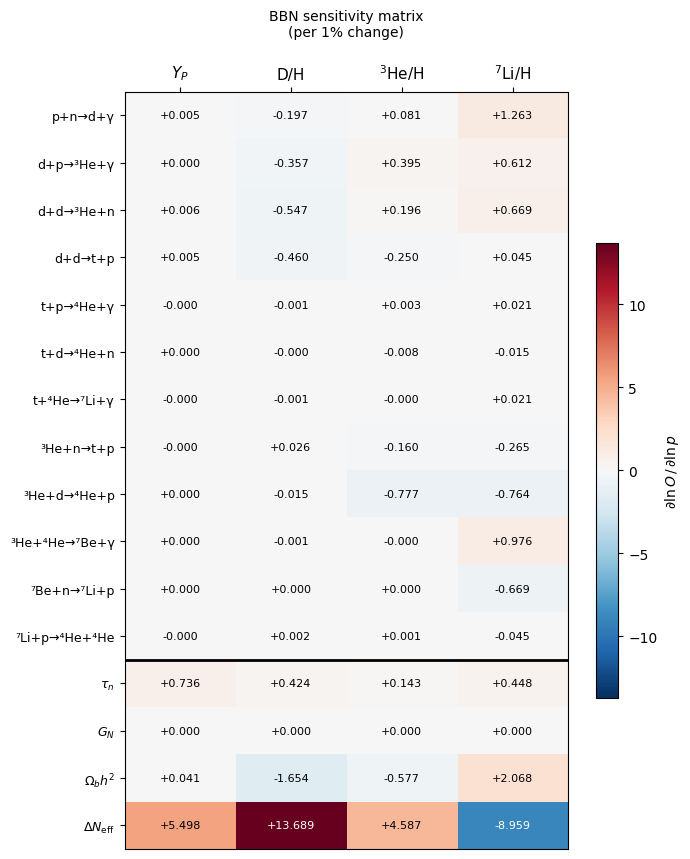

Saved plots/sensitivity_heatmap.pdf


In [10]:
# ---------------------------------------------------------------------------
# Heat-map visualisation
# ---------------------------------------------------------------------------
# The colour encodes the sign and magnitude of the sensitivity.
# Red = positive (parameter up → observable up)
# Blue = negative (parameter up → observable down)

all_labels = RATE_LABELS + phys_names
all_sens   = np.vstack([rate_sens, phys_sens])

fig, ax = plt.subplots(figsize=(7, 0.45 * len(all_labels) + 1.5))

vmax = np.max(np.abs(all_sens))
im = ax.imshow(all_sens, cmap='RdBu_r', vmin=-vmax, vmax=vmax, aspect='auto')

# Annotate each cell with its value
for i in range(len(all_labels)):
    for j in range(len(OBSERVABLES)):
        val = all_sens[i, j]
        color = 'white' if abs(val) > 0.5 * vmax else 'black'
        ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                fontsize=8, color=color)

# Separator line between rates and physical params
ax.axhline(len(RATE_LABELS) - 0.5, color='black', lw=2)

ax.set_xticks(range(len(OBSERVABLES)))
ax.set_xticklabels(OBS_LABELS, fontsize=11)
ax.set_yticks(range(len(all_labels)))
ax.set_yticklabels(all_labels, fontsize=9)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

plt.colorbar(im, ax=ax, label=r'$\partial\ln O\,/\,\partial\ln p$', shrink=0.6)
ax.set_title('BBN sensitivity matrix\n'
             '(per 1% change)',
             fontsize=10, pad=40)

plt.tight_layout()
plt.savefig('plots/sensitivity_heatmap.pdf', bbox_inches='tight')
plt.show()
print("Saved plots/sensitivity_heatmap.pdf")